# Lesson 2 - Exercise 1: Quantifying KV Cache Memory Growth

**Goal:** Empirically measure and analyze the growth in peak GPU memory consumption during LLM inference as the number of generated tokens increases, thereby quantifying the memory footprint of the Key-Value (KV) Cache.

## 2. Imports and Configuration

In [28]:
import os
import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc # For garbage collection
import matplotlib.pyplot as plt

# --- Configuration ---
os.environ["HF_HUB_OFFLINE"] = "1"
model_name = "/voc/shared/models/llama/Llama-3.2-1B"

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("WARNING: This exercise requires a CUDA-enabled GPU for meaningful memory measurements. Results on CPU will not reflect KV cache growth on GPU.")

# TODO: Determine appropriate dtype
if device == "cuda":
    if torch.cuda.is_bf16_supported():
        dtype = torch.bfloat16
        print("Using torch.bfloat16")
    else:
        dtype = torch.float16
        print("Using torch.float16 (bf16 not supported)")
else:
    dtype = torch.float32 # Default for CPU
    print("Using torch.float32 for CPU")

prompt = "The best way to optimize LLM inference is"

# TODO: Define a list of different max_new_tokens values to test.
generation_lengths = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300, 350, 400] 

print(f"Device: {device}")
print(f"Model: {model_name}")
print(f"Prompt: '{prompt}'")
print(f"Generation lengths to test: {generation_lengths}")

Using torch.bfloat16
Device: cuda
Model: /voc/shared/models/llama/Llama-3.2-1B
Prompt: 'The best way to optimize LLM inference is'
Generation lengths to test: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300, 350, 400]


## 3. Helper Function to Measure Peak Memory

In [29]:
def get_peak_gpu_memory_mb(device_to_check="cuda"):
    """Records the peak GPU memory allocated since the last reset for the specified device."""
    if torch.cuda.is_available() and device_to_check == "cuda":
        torch.cuda.synchronize() # Ensure all CUDA operations are complete
        peak_mem_bytes = torch.cuda.memory.max_memory_allocated() # TODO: check the documentation https://docs.pytorch.org/docs/stable/cuda.html for function that can give peak memory
        return peak_mem_bytes / (1024 * 1024) # Convert to MB
    return 0 # Return 0 if not on CUDA or for CPU

## 4. Load Model and Tokenizer

In [30]:
print(f"\nLoading model and tokenizer for {model_name}...")
try:
    # TODO: Load the tokenizer using AutoTokenizer.from_pretrained()
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # TODO: Load the model using AutoModelForCausalLM.from_pretrained()
    #       Specify torch_dtype=dtype and attn_implementation="sdpa"
    #       Move the model to the specified device (.to(device))
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
    ).to(device)

    # TODO: Set tokenizer.pad_token if it's None (e.g., tokenizer.pad_token = tokenizer.eos_token)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = model.config.eos_token_id
        print("Pad token set to EOS token.")

    # TODO: Set the model to evaluation mode using model.eval()
    model.eval()
    print("Model and tokenizer loaded successfully.")
except Exception as e:
    print(f"Error loading model/tokenizer: {e}")
    # exit() # Consider exiting if loading fails


Loading model and tokenizer for /voc/shared/models/llama/Llama-3.2-1B...
Pad token set to EOS token.
Model and tokenizer loaded successfully.


## 5. Test Configuration & Measurement Loop

In [41]:
peak_memory_results_mb = []
actual_tokens_generated_list = []
generation_times = []
extra_memory_results_mb = []

print("\n--- Measuring KV Cache Memory Growth ---")

if device == "cuda" and model is not None: # Proceed only if model loaded and on CUDA
    # Initial memory measurement (model loaded, no generation yet)
    torch.cuda.reset_peak_memory_stats(device) # Reset before taking baseline
    _ = model(torch.tensor([[0]], device=device)) # Dummy forward pass to ensure model is fully on GPU
    torch.cuda.synchronize(device)
    initial_peak_memory_mb = get_peak_gpu_memory_mb(device)
    print(f"Initial peak memory (model loaded on GPU): {initial_peak_memory_mb:.2f} MB")

    for length in generation_lengths:
        print(f"\nGenerating {length} new tokens...")
        
        # TODO: Tokenize the prompt using the loaded tokenizer.
        #       Ensure tensors are moved to the correct device.
        # inputs = tokenizer(prompt, return_tensors="pt").to(device)
        inputs = tokenizer(prompt, return_tensors="pt").to(device) # Placeholder

        if inputs is None:
            print("  Skipping due to uninitialized inputs.")
            peak_memory_results_mb.append(float('nan'))
            actual_tokens_generated_list.append(0)
            generation_times.append(float('nan'))
            continue

        # TODO: Reset GPU memory stats before this specific generation run
        # torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.reset_peak_memory_stats(device)

        start_time = time.perf_counter()
        with torch.no_grad():
            try:
                # TODO: Generate tokens using model.generate()
                #       - Pass inputs["input_ids"]
                #       - Set max_new_tokens=length
                #       - Ensure use_cache=True (it's usually default but good to be explicit)
                #       - Set pad_token_id=tokenizer.pad_token_id
                outputs = model.generate(
                    inputs["input_ids"],
                    max_new_tokens=length,
                    use_cache=True, # This enables/confirms KV Caching
                    pad_token_id=tokenizer.pad_token_id
                )
                if outputs is None:
                    raise ValueError("Outputs from model.generate() is None.")

                # TODO: Calculate actual number of new tokens generated
                num_input_tokens = len(inputs["input_ids"][0])# tokens in the input prompt
                num_output_tokens = len(outputs[0]) # tokens in the output
                actual_new_tokens = num_output_tokens - num_input_tokens
                actual_tokens_generated_list.append(actual_new_tokens)

            except Exception as e:
                print(f"  Error during generation for length {length}: {e}")
                peak_memory_results_mb.append(float('nan')) 
                actual_tokens_generated_list.append(0)
                generation_times.append(float('nan'))
                continue

        # TODO: Synchronize CUDA operations before recording memory and time
        torch.cuda.synchronize(device)
        end_time = time.perf_counter()
        gen_time = end_time - start_time
        generation_times.append(gen_time)

        # TODO: Record peak GPU memory allocated during THIS generation run
        current_peak_memory_mb = get_peak_gpu_memory_mb(device) # Placeholder
        peak_memory_results_mb.append(current_peak_memory_mb)
        extra_memory_mb = current_peak_memory_mb - initial_peak_memory_mb
        extra_memory_results_mb.append(extra_memory_mb)

        print(f"  num_input_tokens: {num_input_tokens}")
        print(f"  num_output_tokens: {num_output_tokens}")
        print(f"  Actual new tokens generated: {actual_new_tokens}")
        print(f"  Peak memory allocated for this generation: {current_peak_memory_mb:.2f} MB")
        print(f"  Extra memory allocated for this generation: {extra_memory_mb:.2f} MB")
        print(f"  Generation time: {gen_time:.4f} seconds")

        # Cleanup
        del outputs
        del inputs
        torch.cuda.empty_cache()
        gc.collect()
else:
    print("Skipping measurement loop: Model not loaded or not on CUDA device.")


--- Measuring KV Cache Memory Growth ---
Initial peak memory (model loaded on GPU): 2371.50 MB

Generating 5 new tokens...


  num_input_tokens: 10
  num_output_tokens: 15
  Actual new tokens generated: 5
  Peak memory allocated for this generation: 2375.97 MB
  Extra memory allocated for this generation: 4.47 MB
  Generation time: 0.2519 seconds

Generating 10 new tokens...
  num_input_tokens: 10
  num_output_tokens: 20
  Actual new tokens generated: 10
  Peak memory allocated for this generation: 2376.13 MB
  Extra memory allocated for this generation: 4.62 MB
  Generation time: 0.2949 seconds

Generating 15 new tokens...
  num_input_tokens: 10
  num_output_tokens: 25
  Actual new tokens generated: 15
  Peak memory allocated for this generation: 2376.29 MB
  Extra memory allocated for this generation: 4.78 MB
  Generation time: 0.4006 seconds

Generating 20 new tokens...
  num_input_tokens: 10
  num_output_tokens: 30
  Actual new tokens generated: 20
  Peak memory allocated for this generation: 2376.44 MB
  Extra memory allocated for this generation: 4.94 MB
  Generation time: 0.5156 seconds

Generating 25

## 6. Deliverables: Analysis and Reporting

In [49]:
print("\n--- Results Summary ---")
print("Max New Tokens | Actual New Tokens | Extra Memory (MB) during Gen | Peak Memory (MB) during Gen |  Time (s) |  AVG MB per token  ")
print("---------------|-------------------|------------------------------|-----------------------------|-----------|--------------------")
for i, requested_length in enumerate(generation_lengths):
    if i < len(peak_memory_results_mb) and i < len(actual_tokens_generated_list) and i < len(generation_times):
        actual_len = actual_tokens_generated_list[i]
        mem_val = peak_memory_results_mb[i]
        time_val = generation_times[i]
        extra_mem_val = extra_memory_results_mb[i]
        mb_per_token = extra_memory_results_mb[i] / actual_len
        print(f"{requested_length:15} | {actual_len:17} | {extra_mem_val:27.2f} | {mem_val:28.2f} | {time_val:8.4f} | {mb_per_token:8.4f}")
    else:
        # This case handles if a generation run failed and wasn't recorded
        print(f"{requested_length:15} | {'N/A':17} | {'N/A':27} | {'N/A':8}")


delta_peak_memory = peak_memory_results_mb[-1] - peak_memory_results_mb[0]
delta_extra_memory = extra_memory_results_mb[-1] - extra_memory_results_mb[0]
delta_tokens_count = actual_tokens_generated_list[-1] - actual_tokens_generated_list[0]
print('\n'*3)
print(f'delta_peak_memory: {delta_peak_memory}')
print(f'delta_extra_memory: {delta_extra_memory}')
print(f'delta_tokens_count: {delta_tokens_count}')
print('\n'*3)
print(f'Peak MB per token: {delta_peak_memory/delta_tokens_count}')
print(f'Extra MB per token: {delta_extra_memory/delta_tokens_count}')




--- Results Summary ---
Max New Tokens | Actual New Tokens | Extra Memory (MB) during Gen | Peak Memory (MB) during Gen |  Time (s) |  AVG MB per token  
---------------|-------------------|------------------------------|-----------------------------|-----------|--------------------
              5 |                 5 |                        4.47 |                      2375.97 |   0.2519 |   0.8937
             10 |                10 |                        4.62 |                      2376.13 |   0.2949 |   0.4625
             15 |                15 |                        4.78 |                      2376.29 |   0.4006 |   0.3187
             20 |                20 |                        4.94 |                      2376.44 |   0.5156 |   0.2469
             25 |                25 |                        5.09 |                      2376.60 |   0.6315 |   0.2037
             30 |                30 |                        5.25 |                      2376.75 |   0.7668 |   0.1750
 

In [43]:

def plot_graph(data, model_name, title, x_label, y_label):
    # --- Plotting ---
    if device == "cuda" and any(m > 0 for m in data if isinstance(m, (int, float)) and not torch.isnan(torch.tensor(m))):
        # Filter out NaN or non-numeric before plotting
        valid_indices = [i for i, mem in enumerate(data) 
                        if isinstance(mem, (int, float)) and not torch.isnan(torch.tensor(mem))]
        plot_lengths = [actual_tokens_generated_list[i] for i in valid_indices]
        plot_memory = [data[i] for i in valid_indices]
        
        if plot_lengths and plot_memory and len(plot_lengths) == len(plot_memory):
            try:
                plt.figure(figsize=(10, 6))
                plt.plot(plot_lengths, plot_memory, marker='o', linestyle='-')
                plt.title(f'{title}: {model_name}')
                plt.xlabel(x_label)
                plt.ylabel(y_label)
                plt.grid(True)
                # plt.xticks(plot_lengths) # May be too crowded if many points
                plt.tight_layout()
                plot_filename = f"kv_cache_memory_growth_{x_label}_{y_label}.png"
                plt.savefig(plot_filename)
                print(f"\nPlot saved to {plot_filename}")
                plt.show()
            except Exception as e:
                print(f"Could not generate plot: {e}. Ensure matplotlib is installed.")
        else:
            print("Not enough valid data points to plot.")
    elif device != "cuda":
        print("\nPlotting is designed for CUDA memory measurements.")




Plot saved to kv_cache_memory_growth_Number of Actual New Tokens Generated_Peak GPU Memory Allocated During Generation (MB).png


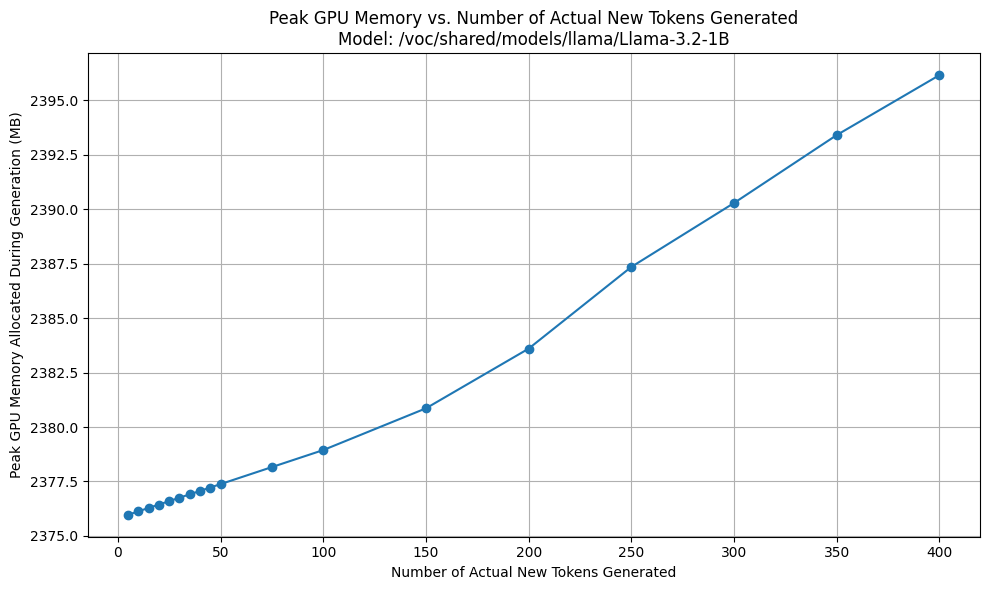

In [44]:
plot_graph(
        peak_memory_results_mb,
        model_name,
        "Peak GPU Memory vs. Number of Actual New Tokens Generated\nModel",
        'Number of Actual New Tokens Generated',
        'Peak GPU Memory Allocated During Generation (MB)'
    )


Plot saved to kv_cache_memory_growth_Number of Actual New Tokens Generated_Extra GPU Memory Allocated During Generation (MB).png


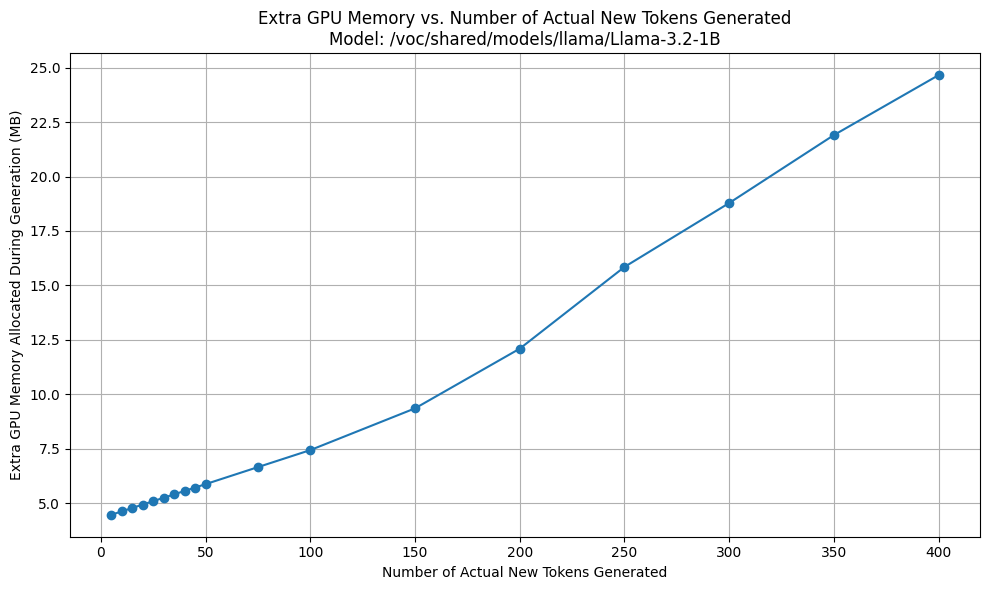

In [45]:
plot_graph(
    extra_memory_results_mb,
    model_name,
    "Extra GPU Memory vs. Number of Actual New Tokens Generated\nModel",
    'Number of Actual New Tokens Generated',
    'Extra GPU Memory Allocated During Generation (MB)'
)

In [46]:

print("\nExercise Complete. Please fill in the TODO sections for analysis.")


Exercise Complete. Please fill in the TODO sections for analysis.


## Trend Analysis:
1. Describe the relationship you observe between 'Actual New Tokens' and 'Peak Memory (MB) during Gen'.
   Is it linear? Does it increase as expected?
   (You can also consider 'Peak Memory (MB) during Gen' - initial_peak_memory_mb to see the growth above the model size).

Answer:
it's linear, but it doesn't start at zero, as the model uses memory for parameters and the memory for the previous tokens, and the grouth is because the increase of the sequence increase the number of tokens stored at the meomory

## Estimate Memory per Token:
2. Calculate an estimate of how much *additional* memory the KV cache consumes per *actually generated new token*.
   - Select two data points from your results (e.g., generation for 50 tokens and 150 tokens).
   - Calculate ΔMemory = PeakMemory_LongerRun - PeakMemory_ShorterRun
   - Calculate ΔTokens = ActualTokens_LongerRun - ActualTokens_ShorterRun
   - Estimate MemoryPerToken = ΔMemory / ΔTokens (if ΔTokens > 0)
   - Print your chosen data points and the calculated memory per token.

Answer: calculated down the memory tokens table
delta_peak_memory: 20.19091796875
delta_extra_memory: 20.19091796875
delta_tokens_count: 395

Peak MB per token: 0.0511162480221519
Extra MB per token: 0.0511162480221519

## Practical Impact Discussion:
3. Briefly discuss how this growing KV cache memory footprint can become a limiting factor for generating 
   very long sequences, especially on GPUs with constrained VRAM. How does this relate to the concept 
   of "context window limits" in practice (even if the model theoretically supports a large window)?

While having the KV cache enabled, memory increases linearly, as new tokens KVs are cached to the memory, and as it grows, we might hit  the memory limit and cause the system to fails, so despite the model might be accepting long sequences, the GPU might not be able to cover the memory needed for long contexts
